# 18.3 · Occlusion, gating and track lifetime

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain occlusion, gating and track lifetime using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[12 · Contours and Shapes](../../12-contours-and-shapes/README.md), [15 · Video Processing](../../15-video-processing/README.md), [17 · Motion Detection](../../17-motion-detection/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

Tracking estimates an object state over time. Detection supplies observations; a motion model predicts where the object might be next. Keeping uncertainty explicit allows a tracker to bridge short missing detections without pretending its prediction is a measurement.

## 2. Intuition

Gating rejects observations too far from a predicted state. During a missing detection, a track predicts forward and its uncertainty grows. A maximum missed-frame policy eventually deletes it. Template-based trackers such as correlation filters and detector-assisted tracking use different observations; neither guarantees identity through long occlusion.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 18
LESSON = 2
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
x_{t+1}=x_t+v_x\Delta t
$$

x is horizontal position, vx horizontal velocity and Δt elapsed time. At x=10 px, velocity 3 px/s and Δt=0.5 s, predicted x is 11.5 px. This model assumes constant velocity over that interval.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
position, velocity, dt = 10.0, 3.0, 0.5
prediction = position + velocity * dt
assert np.isclose(prediction, 11.5)
print(prediction)

11.5


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

The tracker predicts state/covariance, associates gated observations, corrects matched tracks and expires stale tracks. The lab compares noisy centers and filtered positions against known trajectories.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def single_tracking(lesson, seed, amount):
    rng = np.random.default_rng(seed)
    truth = np.c_[np.arange(20) * 3 + 10, np.ones(20) * 40]
    measurements = truth + rng.normal(0, 2 * amount, truth.shape)
    tracker = KalmanTracker()
    estimates = []
    for index, measurement in enumerate(measurements):
        detection = [] if lesson == 2 and 8 <= index <= 10 else [measurement]
        tracks = tracker.update(detection)
        estimates.append(tracks[0].state[:2].copy())
    estimates = np.array(estimates)
    return Result(
        "18 · State prediction, updates and short occlusion",
        curves={
            "True x": truth[:, 0],
            "Measured x": measurements[:, 0],
            "Tracked x": estimates[:, 0],
        },
        panels={"XY trajectory": np.vstack([truth[:, 0], measurements[:, 0], estimates[:, 0]])},
        metrics={
            "measurement_rmse_px": float(np.sqrt(np.mean((measurements - truth) ** 2))),
            "tracking_rmse_px": float(np.sqrt(np.mean((estimates - truth) ** 2))),
        },
    )

{
  "measurement_rmse_px": 1.6327173175714513,
  "tracking_rmse_px": 1.1879270460532962
}



## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/tracking.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.tracking import KalmanTracker

display(Code(inspect.getsource(KalmanTracker), language="python"))

class KalmanTracker:
    """Track XY centers; anonymous IDs, constant-velocity model and distance gating.

    This teaches SORT's ingredients, but is not a reproduction of SORT/DeepSORT:
    there is no box-size state or learned appearance embedding.
    """

    def __init__(self, gate=25.0, max_missed=4):
        self.gate, self.max_missed = gate, max_missed
        self.tracks = []
        self.next_identity = 1

    def update(self, centers, dt=1.0):
        centers = np.asarray(centers, float).reshape(-1, 2)
        if dt <= 0:
            raise ValueError("dt must be positive.")
        f = np.array([[1, 0, dt, 0], [0, 1, 0, dt], [0, 0, 1, 0], [0, 0, 0, 1.0]])
        h = np.eye(2, 4)
        q = (
            np.array(
                [
                    [dt**4 / 4, 0, dt**3 / 2, 0],
                    [0, dt**4 / 4, 0, dt**3 / 2],
                    [dt**3 / 2, 0, dt**2, 0],
                    [0, dt**3 / 2, 0, dt**2],
                ]
            )
            * 0.1
        )
        for track in self.tracks:
            track.state = f @ track.state
            track.covariance = f @ track.covariance @ f.T + q
            track.missed += 1
        matched = set()
        if self.tracks and len(centers):
            costs = np.linalg.norm(
                np.array([t.state[:2] for t in self.tracks])[:, None] - centers, axis=2
            )
            rows, cols = linear_sum_assignment(np.where(costs <= self.gate, costs, 1e6))
            for row, col in zip(rows, cols, strict=True):
                if costs[row, col] > self.gate:
                    continue
                track = self.tracks[row]
                residual = centers[col] - h @ track.state
                s = h @ track.covariance @ h.T + np.eye(2) * 2
                gain = np.linalg.solve(s, h @ track.covariance).T
                track.state += gain @ residual
                a = np.eye(4) - gain @ h
                track.covariance = a @ track.covariance @ a.T + gain @ (np.eye(2) * 2) @ gain.T
                track.missed = 0
                matched.add(col)
        self.tracks = [t for t in self.tracks if t.missed <= self.max_missed]
        for index, center in enumerate(centers):
            if index not in matched:
                self.tracks.append(
                    Track(self.next_identity, np.r_[center, 0.0, 0.0], np.eye(4) * 10)
                )
                self.next_identity += 1
        for track in self.tracks:
            track.history.append(track.state[:2].tolist())
            track.history = track.history[-100:]
        return self.tracks

## 8. Experiment

Increase measurement noise and insert a short occlusion. Plot position error and inspect uncertainty rather than judging smoothness alone.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "measurement_rmse_px": 1.6327173175714513,
    "tracking_rmse_px": 1.1879270460532962
  },
  "second_seed": {
    "measurement_rmse_px": 2.0041675031146444,
    "tracking_rmse_px": 1.3975625666956424
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

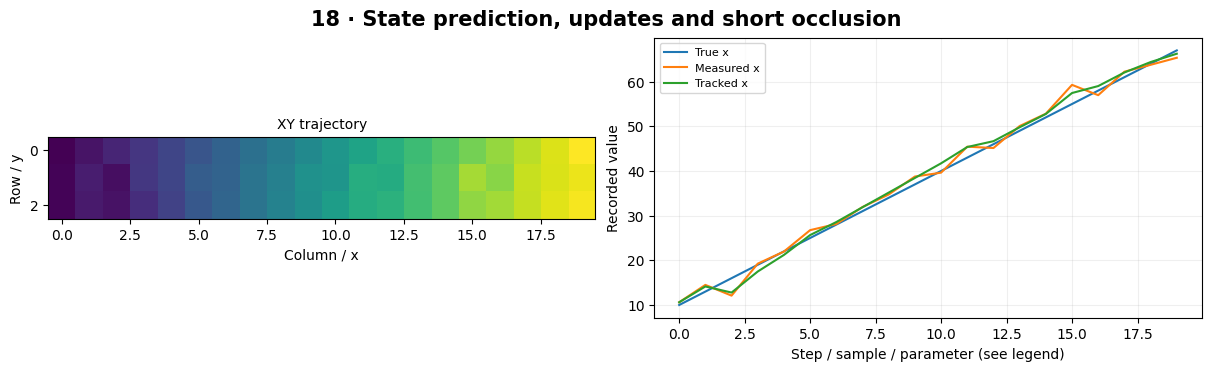

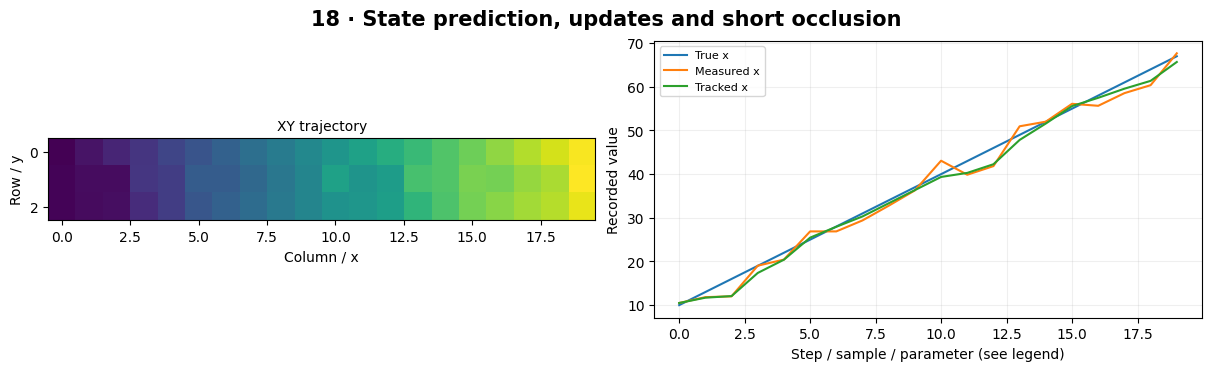

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Ball Tracker**. Follow a visible object and explain when its identity is uncertain. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

A smooth trajectory can still be wrong. Pixel velocity changes when FPS changes unless elapsed time is included.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Increase measurement noise and insert a short occlusion. Plot position error and inspect uncertainty rather than judging smoothness alone.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Track a ball with a detector and motion model, report lost periods, and distinguish observed positions from predictions.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

Gating rejects observations too far from a predicted state. During a missing detection, a track predicts forward and its uncertainty grows. A maximum missed-frame policy eventually deletes it. Template-based trackers such as correlation filters and detector-assisted tracking use different observations; neither guarantees identity through long occlusion.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

[19 · Face Detection](../../19-face-detection/README.md)

[Primary reference](https://docs.opencv.org/4.x/dd/d6a/classcv_1_1KalmanFilter.html) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)